## NVIDIA Corporation (NVDA)  Exploratory Data Analysis

### Overview
This notebook presents an exploratory data analysis (EDA) of financial news headlines related to **NVIDIA Corporation (NVDA)**. The analysis is part of a broader project at **Nova Financial Solutions** aimed at building a predictive analytics pipeline that connects market narratives to stock price movements.

### Objectives
- Understand the structure and statistical properties of the financial news dataset
- Identify common keywords, themes, and topics in NVDA-related headlines
- Analyze publication trends and volume spikes over time
- Examine publisher activity and contribution patterns

### Dataset
The analysis uses the **Financial News and Stock Price Integration Dataset (FNSPID)**, which contains financial news headlines, publication dates, publisher information, and associated stock ticker symbols.

## 1. Import Libraries

In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from src.data_loader import load_news_data, filter_by_stock
from src.text_analyzer import (
    clean_headline,
    get_tfidf_keywords,
    get_word_frequency,
    get_lda_topics,
    extract_email_domains
)
from src.visualizer import (
    plot_headline_length,
    plot_publisher_activity,
    plot_email_domains,
    plot_time_series,
    plot_keywords,
    plot_lda_topics
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ All libraries imported successfully!


## 2. Loading the Data

We load the raw financial news dataset using our modular `load_news_data()` function from `src/data_loader.py`. This keeps our notebook clean and ensures consistent data loading across all notebooks.

In [16]:
df = load_news_data('../data/raw/raw_analyst_ratings.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

✅ Loaded 1407328 news articles.
Dataset Shape: (1407328, 5)

Column Names: ['headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


## 3. Data Filtering

We filter the dataset for **NVDA** articles only using our modular `filter_by_stock()` function. The cleaning was already handled inside `load_news_data()`.

In [17]:
nvda_df = filter_by_stock(df, 'NVDA')

print(f"\nDate range: {nvda_df['date'].min().date()} to {nvda_df['date'].max().date()}")
print(f"\nMissing values:\n{nvda_df.isnull().sum()}")
nvda_df.head()

✅ Found 3146 articles for NVDA.

Date range: 2011-03-03 to 2020-06-10

Missing values:
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16224173/s...,Benzinga Newsdesk,2020-06-10 16:37:10+00:00,NVDA
1,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622357...,Benzinga Insights,2020-06-10 16:12:25+00:00,NVDA
2,Morning Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1622174...,Benzinga Insights,2020-06-10 14:22:11+00:00,NVDA
3,Shares of several technology companies are tra...,https://www.benzinga.com/wiim/20/06/16214789/s...,Benzinga Newsdesk,2020-06-09 17:40:43+00:00,NVDA
4,Afternoon Market Stats in 5 Minutes,https://www.benzinga.com/markets/20/06/1620319...,Benzinga Insights,2020-06-08 16:30:29+00:00,NVDA


## 4. Descriptive Statistics

In this section we examine the basic statistical properties of the dataset including headline length distribution, article count over time, and a general summary of the data.

In [18]:
nvda_df['headline_length'] = nvda_df['headline'].apply(len)

print("=== Headline Length Statistics ===")
print(nvda_df['headline_length'].describe())

print(f"\n=== Sample Headlines ===")
for h in nvda_df['headline'].sample(5, random_state=42).values:
    print(f"• {h}")

=== Headline Length Statistics ===
count    3146.000000
mean       76.813732
std        47.904001
min        16.000000
25%        47.000000
50%        64.000000
75%        85.000000
max       382.000000
Name: headline_length, dtype: float64

=== Sample Headlines ===
• Canaccord Downgrades NVIDIA to Hold, $15 PT
• Stocks Which Set New 52-Week High Yesterday, August 30th
• Is It Time To Remove General Electric From The Dow 30?
• Stocks That Made New 52-Wk Highs Earlier Include: Accenture, M&T Bank, PNC, Ansys, Lockheed Martin, Deere, Raytheon, Intuit, Comerica, Interpuclic, Northrop Grumman, VeriSign, Estee Lauder, Bristol-Myers, Red Hat, Nike, NVIDIA and Global Payments
• Benzinga's Top ETF Gainers, August 23rd (SOXL, TNA, ERX, TQQQ)


### 4.1 Headline Length Distribution

We visualize the distribution of headline character lengths to understand how concise or verbose the financial news headlines tend to be.

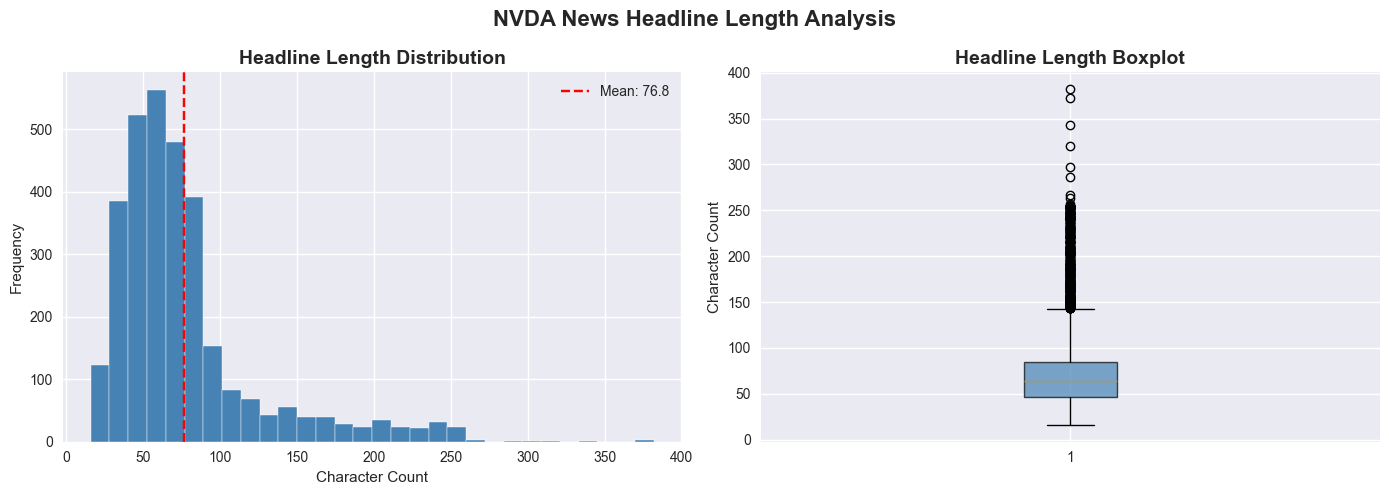

In [19]:
plot_headline_length(nvda_df, 'NVDA')

## 5. Publisher Analysis

We identify the most active publishers contributing to NVDA-related news. Understanding which sources dominate the coverage helps assess potential bias and the diversity of market perspectives.

In [20]:
publisher_counts = nvda_df['publisher'].value_counts()

print(f"Total unique publishers: {publisher_counts.nunique()}")
print(f"\nTop 10 most active publishers:")
print(publisher_counts.head(10))

Total unique publishers: 40

Top 10 most active publishers:
publisher
Benzinga Newsdesk    453
Lisa Levin           357
Paul Quintaro        293
Charles Gross        191
Wayne Duggan         144
Jayson Derrick       126
Monica Gerson        126
Shanthi Rexaline     118
JJ Kinahan           101
Craig Jones           92
Name: count, dtype: int64


### 5.1 Publisher Activity Visualization

The bar chart below highlights the dominance of certain publishers in NVDA news coverage, particularly **Benzinga Newsdesk** which accounts for the majority of articles.

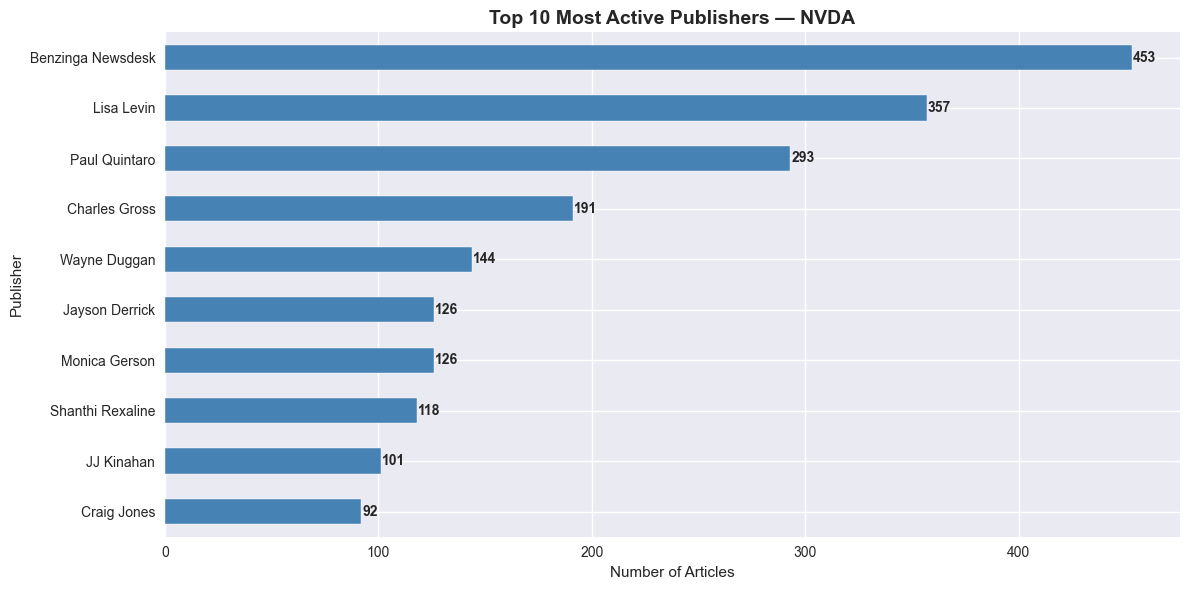

In [21]:
plot_publisher_activity(publisher_counts, 'NVDA')

### 5.2 Email Publisher Domain Analysis

Some publishers use email addresses as their names. We extract the domain from these emails to identify the organizations contributing to the news coverage.

Articles from email-based publishers: 24
Unique email publishers: 3

Top domains:
         domain  count
0  benzinga.com     23
1     gmail.com      1


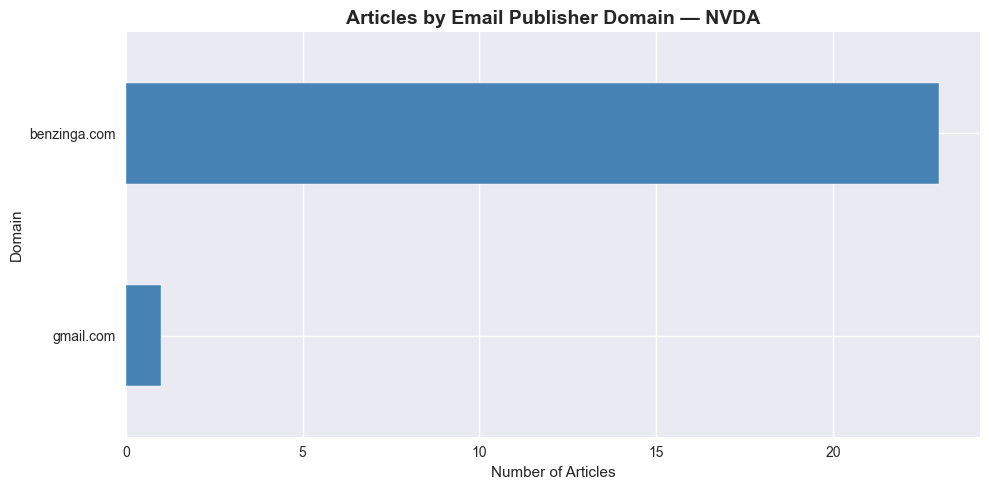

In [22]:
email_pubs = nvda_df[nvda_df['publisher'].str.contains('@', na=False)]
print(f"Articles from email-based publishers: {len(email_pubs)}")
print(f"Unique email publishers: {email_pubs['publisher'].nunique()}")

domain_counts = extract_email_domains(nvda_df)
print(f"\nTop domains:\n{domain_counts}")

plot_email_domains(domain_counts, 'NVDA')

## 6. Time Series Analysis of News Volume

We analyze how NVDA-related article publication frequency varies over time. Spikes in news volume often correlate with significant market events such as earnings releases, product launches, or macroeconomic developments.

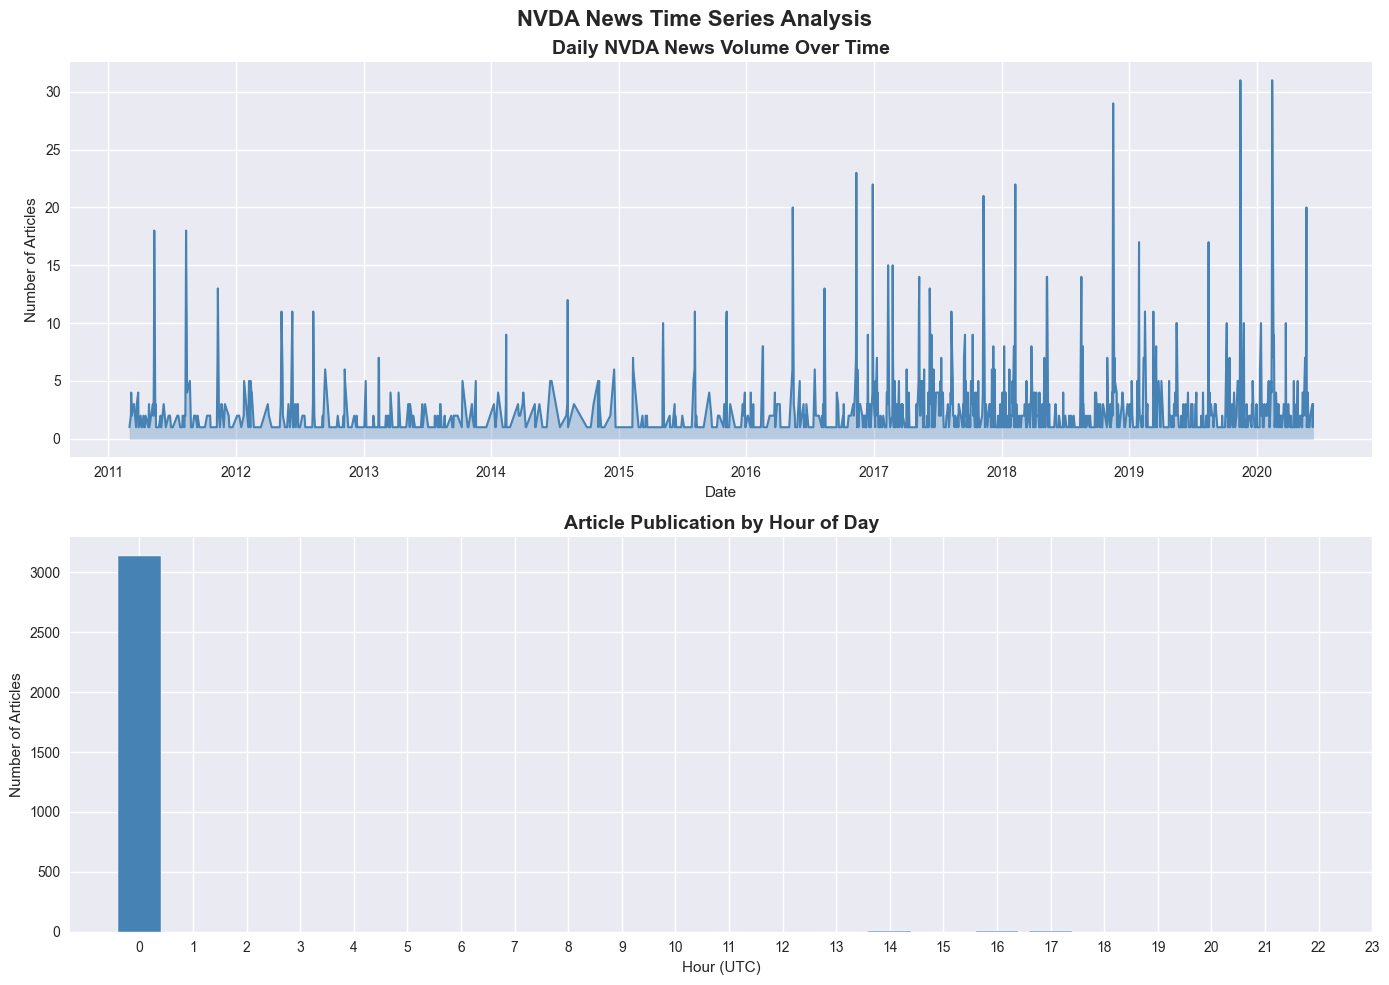

In [23]:
nvda_df['date_only'] = nvda_df['date'].dt.date
nvda_df['hour'] = nvda_df['date'].dt.hour
nvda_df['day_of_week'] = nvda_df['date'].dt.day_name()

daily_counts = nvda_df.groupby('date_only').size()

plot_time_series(nvda_df, daily_counts, 'NVDA')

## 7. Text Analysis & Topic Modeling

We apply NLP techniques to extract the most frequent keywords and themes from NVDA-related headlines using three complementary approaches: **TF-IDF**, **CountVectorizer**, and **LDA Topic Modeling**.

In [24]:
nvda_df['cleaned_headline'] = nvda_df['headline'].apply(clean_headline)

tfidf_matrix, tfidf_keywords, tfidf_scores = get_tfidf_keywords(
    nvda_df['cleaned_headline'])
word_freq = get_word_frequency(nvda_df['cleaned_headline'])

print("Top 20 Keywords (TF-IDF):")
print(tfidf_keywords)
print(f"\nTop 20 Keywords (Frequency):")
print(word_freq)

Top 20 Keywords (TF-IDF):
['amd' 'benzingas' 'buy' 'earnings' 'higher' 'maintains' 'market' 'nvidia'
 'nvidia shares' 'price' 'price target' 'raises' 'semiconductor' 'shares'
 'stock' 'stocks' 'target' 'top' 'trading' 'update']

Top 20 Keywords (Frequency):
          keyword  frequency
7          nvidia       1479
15         stocks        381
13         shares        368
3        earnings        282
16         target        264
9           price        249
6          market        226
10   price target        225
18        trading        199
17            top        198
5       maintains        182
12  semiconductor        174
14          stock        172
4          higher        172
11         raises        170
19         update        162
2             buy        157
1       benzingas        155
0             amd        152
8   nvidia shares        139


### 7.1 Top Keywords Visualization

The most frequently occurring keywords reveal the dominant themes in NVDA news coverage. Notable themes include semiconductor industry dynamics with frequent mentions of AMD as a key competitor, consistent analyst price target raises, and earnings outperformance — reflecting NVIDIA's dominant position in the GPU market during 2020.

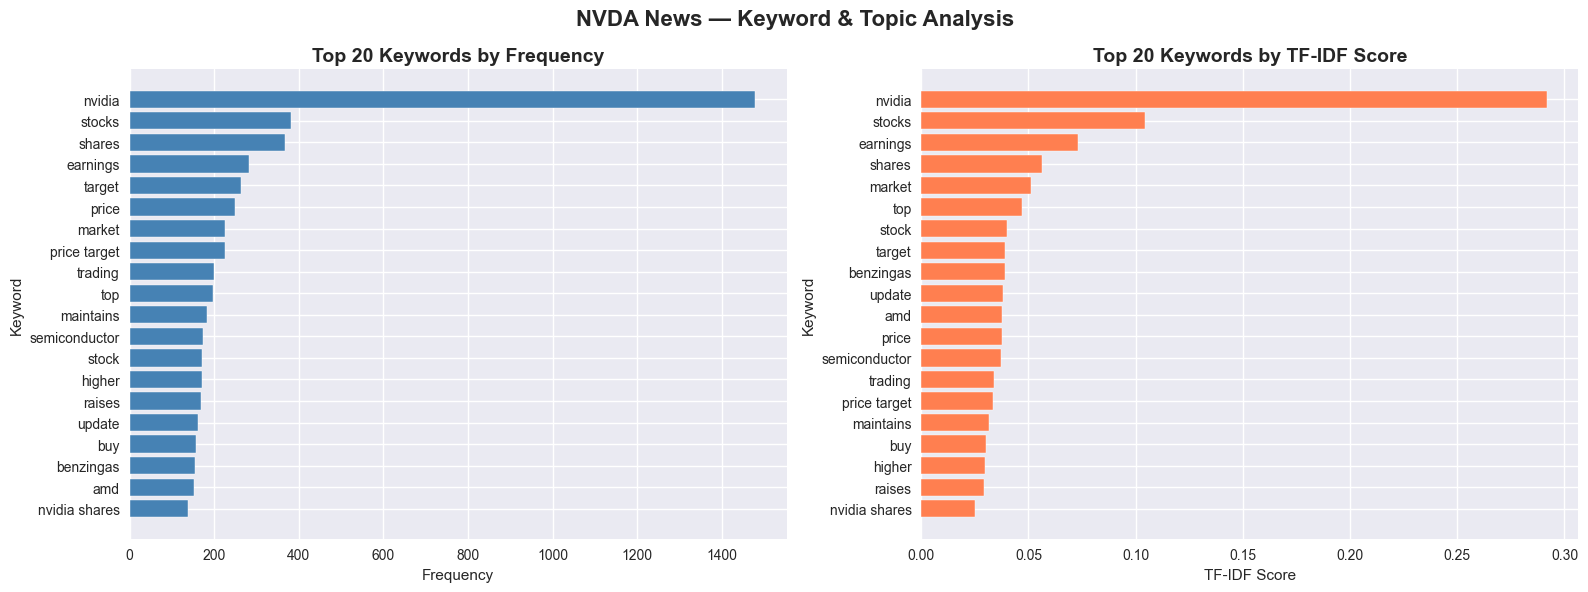

In [25]:
plot_keywords(word_freq, tfidf_keywords, tfidf_scores, 'NVDA')

### 7.2 LDA Topic Modeling

Latent Dirichlet Allocation (LDA) is an unsupervised machine learning technique that discovers hidden topics in a collection of documents. We use LDA to identify the main themes discussed in NVDA-related headlines.

=== LDA Topic Modeling Results ===
Number of topics: 5

Topic 1: stocks, shares, trading, semiconductor, higher, companies, several, technology, session, week
Topic 2: nvidia, update, est, says, sees, sales, reports, market, gaming, analyst
Topic 3: nvidia, stock, top, etf, bank, ahead, markets, amd, futures, nvidias
Topic 4: nvidia, earnings, top, benzingas, market, upgrades, downgrades, report, tesla, shares
Topic 5: nvidia, target, price, maintains, raises, buy, alert, option, nvda, outperform


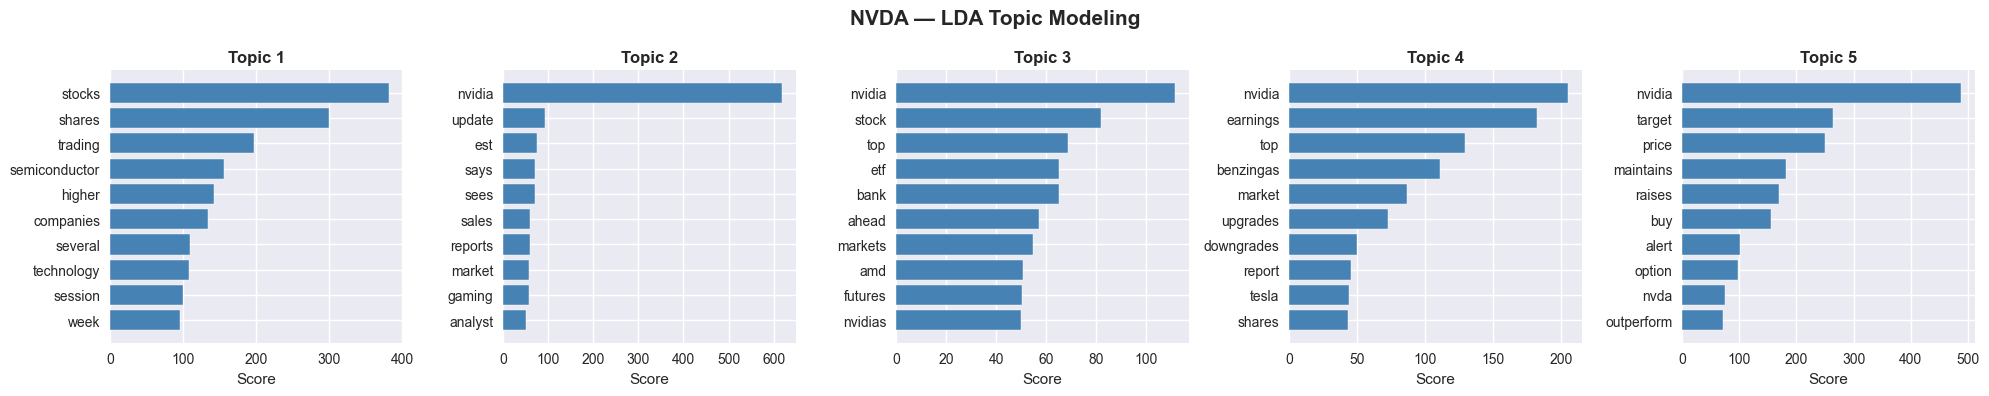

In [26]:
lda_model, feature_names, topics = get_lda_topics(
    nvda_df['cleaned_headline'], n_topics=5)

print("=== LDA Topic Modeling Results ===")
print(f"Number of topics: 5\n")
for i, topic in enumerate(topics):
    print(f"Topic {i+1}: {', '.join(topic)}")

plot_lda_topics(lda_model, feature_names, 5, 'NVDA')

## 8. Key Findings & Summary

A summary of the most important insights derived from the exploratory data analysis of NVDA-related financial news headlines.

In [27]:
print("=" * 55)
print("        NVDA EDA — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"""
📰 DATASET OVERVIEW
- Total NVDA articles analyzed : {len(nvda_df)}
- Date range                   : {nvda_df['date'].min().date()} to {nvda_df['date'].max().date()}
- Unique publishers            : {nvda_df['publisher'].nunique()}

📏 HEADLINE STATISTICS
- Average headline length      : {nvda_df['headline_length'].mean():.1f} characters
- Shortest headline            : {nvda_df['headline_length'].min()} characters
- Longest headline             : {nvda_df['headline_length'].max()} characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : {nvda_df['publisher'].value_counts().index[0]}
- Articles by top publisher    : {nvda_df['publisher'].value_counts().iloc[0]}

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : {daily_counts.max()} articles
- Date of highest volume       : {daily_counts.idxmax()}

🔑 TOP THEMES IDENTIFIED
- Semiconductor industry & AMD competition
- Price target raises & analyst upgrades
- Earnings performance & revenue growth
- GPU & technology market leadership
- Stock trading & investor sentiment
""")
print("=" * 55)

        NVDA EDA — KEY FINDINGS SUMMARY

📰 DATASET OVERVIEW
- Total NVDA articles analyzed : 3146
- Date range                   : 2011-03-03 to 2020-06-10
- Unique publishers            : 151

📏 HEADLINE STATISTICS
- Average headline length      : 76.8 characters
- Shortest headline            : 16 characters
- Longest headline             : 382 characters

📰 PUBLISHER INSIGHTS
- Most active publisher        : Benzinga Newsdesk
- Articles by top publisher    : 453

📈 NEWS VOLUME INSIGHTS
- Highest single day volume    : 31 articles
- Date of highest volume       : 2019-11-15

🔑 TOP THEMES IDENTIFIED
- Semiconductor industry & AMD competition
- Price target raises & analyst upgrades
- Earnings performance & revenue growth
- GPU & technology market leadership
- Stock trading & investor sentiment



## 8. Conclusion

The EDA of NVDA financial news reveals the largest dataset among all analyzed companies, reflecting NVIDIA's massive media presence in the semiconductor space. Coverage is dominated by **analyst upgrades**, **price target raises**, and **semiconductor industry competition** — particularly with AMD.

**Benzinga Newsdesk** remains the dominant publisher. NVIDIA's narrative during this period was overwhelmingly **growth-oriented**, driven by GPU demand from gaming, data centers, and AI workloads.

These insights will inform the sentiment analysis and correlation study in the subsequent notebook.